#**Employee Performance Prediction System**

####Objective
The objective of this project is to build a machine learning classification model that predicts whether a newly hired employee is likely to become a High Performer based on early performance indicators.

**Made by: Manish Dhoundiyal**

##**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

##**Load Dataset**

In [3]:
df = pd.read_excel("Employee_Performance_Dataset.xlsx")
df.head()

,Employee_ID,Department,Experience_Level,Training_Hours,Attendance_Percentage,Tasks_Completed,Assessment_Score,Manager_Feedback,Projects_Assigned,Average_Task_Completion_Time,High_Performer
0,EMP001,IT,Junior,42,98,55,91,Excellent,4,3.8,Yes
1,EMP002,HR,Junior,18,88,29,67,Average,2,7.5,No
2,EMP003,Sales,Mid,30,94,46,83,Good,3,4.8,Yes
3,EMP004,Finance,Senior,15,82,31,61,Average,2,6.9,No
4,EMP005,Marketing,Mid,35,96,48,87,Excellent,4,4.1,Yes


##**Dataset Shape**

In [4]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 40
Columns : 11


##**Dataset Information**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Employee_ID                   40 non-null     object 
 1   Department                    40 non-null     object 
 2   Experience_Level              40 non-null     object 
 3   Training_Hours                40 non-null     int64  
 4   Attendance_Percentage         40 non-null     int64  
 5   Tasks_Completed               40 non-null     int64  
 6   Assessment_Score              40 non-null     int64  
 7   Manager_Feedback              40 non-null     object 
 8   Projects_Assigned             40 non-null     int64  
 9   Average_Task_Completion_Time  40 non-null     float64
 10  High_Performer                40 non-null     object 
dtypes: float64(1), int64(5), object(5)
memory usage: 3.6+ KB


##**Missing Values**

In [6]:
df.isnull().sum()

,0
Employee_ID,0
Department,0
Experience_Level,0
Training_Hours,0
Attendance_Percentage,0
Tasks_Completed,0
Assessment_Score,0
Manager_Feedback,0
Projects_Assigned,0
Average_Task_Completion_Time,0


##**Duplicate Values**

In [7]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


##**Summary Statistics**

In [8]:
df.describe()

,Training_Hours,Attendance_Percentage,Tasks_Completed,Assessment_Score,Projects_Assigned,Average_Task_Completion_Time
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,24.825000,90.075000,40.275000,76.900000,3.025000,5.460000
std,9.317443,6.010194,10.233147,11.973903,1.143263,1.463189
min,10.000000,78.000000,22.000000,55.000000,1.000000,3.400000
25%,17.750000,85.750000,31.750000,67.750000,2.000000,4.175000
50%,23.500000,90.500000,40.000000,77.500000,3.000000,5.250000
75%,32.250000,95.250000,48.250000,87.250000,4.000000,6.475000
max,42.000000,99.000000,58.000000,96.000000,5.000000,8.500000


##**Target Value Distribution**

In [9]:
df["High_Performer"].value_counts()

,count
High_Performer,
Yes,24
No,16


##**First Visualization**

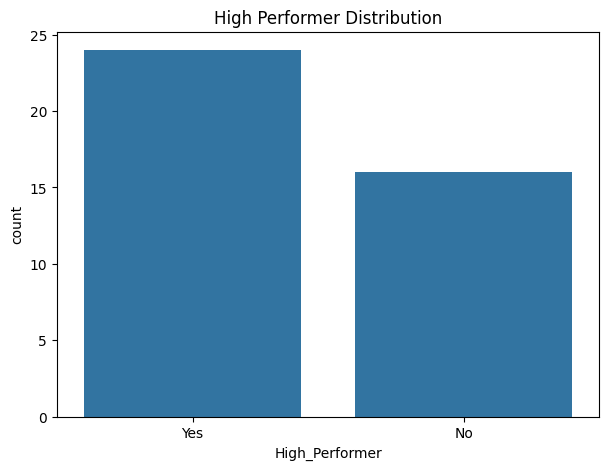

In [10]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="High_Performer")
plt.title("High Performer Distribution")
plt.show()

##**Second Visualization**

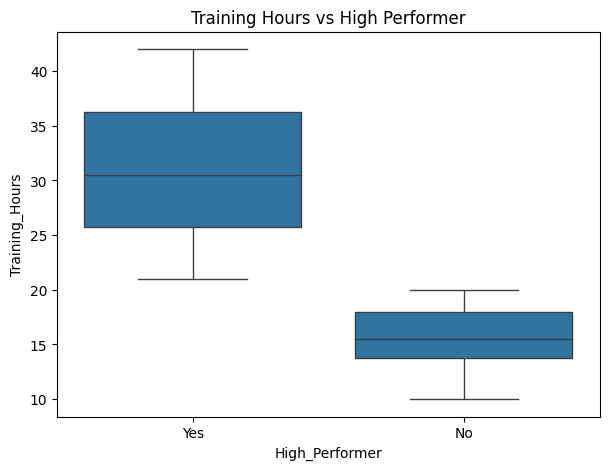

In [12]:
plt.figure(figsize=(7,5))
sns.boxplot(x='High_Performer', y='Training_Hours', data=df)
plt.title("Training Hours vs High Performer")
plt.show()

##**Third Visualiztion**

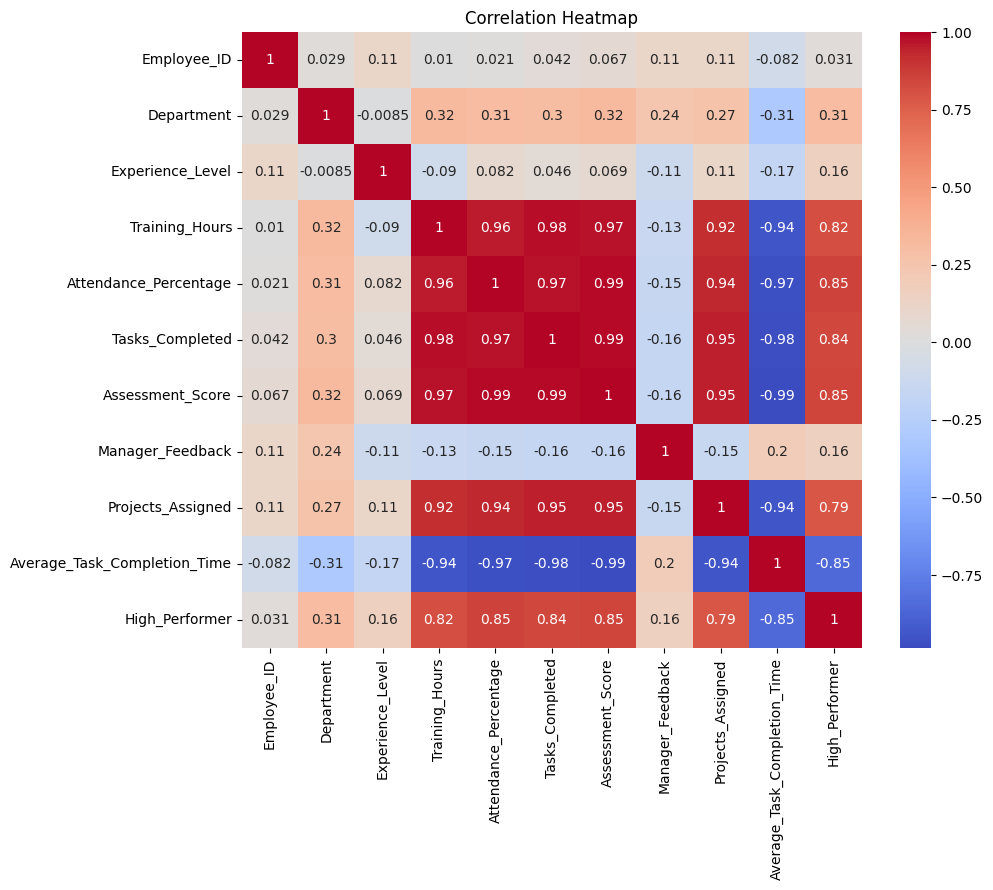

In [13]:
df_corr = df.copy()
le = LabelEncoder()
for col in df_corr.select_dtypes(include='object'):
    df_corr[col] = le.fit_transform(df_corr[col])

plt.figure(figsize=(10,8))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

##**Data Preprocessing**

In [14]:
# Remove Employee ID
df = df.drop("Employee_ID", axis=1)
# Label Encoding
encoder = LabelEncoder()
for col in df.select_dtypes(include="object"):
    df[col] = encoder.fit_transform(df[col])

# Features and Target
X = df.drop("High_Performer", axis=1)
y = df["High_Performer"]
print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (40, 9)
Target Shape : (40,)


##**Train Test Split**

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

##**Feature Scaling**

In [16]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (32, 9)
Testing Samples : (8, 9)


##**Logistic Regression**

In [19]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)
print("LOGISTIC REGRESSION RESULTS")
print("Accuracy :", lr_accuracy)
print("Precision :", lr_precision)
print("Recall :", lr_recall)
print("F1 Score :", lr_f1)
print("\nClassification Report\n")
print(classification_report(y_test, lr_pred))

LOGISTIC REGRESSION RESULTS
Accuracy : 0.875
Precision : 0.8571428571428571
Recall : 1.0
F1 Score : 0.9230769230769231

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.86      1.00      0.92         6

    accuracy                           0.88         8
   macro avg       0.93      0.75      0.79         8
weighted avg       0.89      0.88      0.86         8



##**Decision Tree**

In [20]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)
print("DECISION TREE RESULTS")
print("Accuracy :", dt_accuracy)
print("Precision :", dt_precision)
print("Recall :", dt_recall)
print("F1 Score :", dt_f1)

print("\nClassification Report\n")
print(classification_report(y_test, dt_pred))

DECISION TREE RESULTS
Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1 Score : 1.0

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         6

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



##**Model Comparision**

In [23]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [lr_accuracy, dt_accuracy],
    "Precision": [lr_precision, dt_precision],
    "Recall": [lr_recall, dt_recall],
    "F1 Score": [lr_f1, dt_f1]
})
comparison = comparison.round(3)
comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.875,0.857,1.0,0.923
1,Decision Tree,1.000,1.000,1.0,1.000


#**HR Recommendations**

- Encourage employees to complete more training sessions.
- Monitor attendance regularly to improve productivity.
- Provide additional support to employees with low assessment scores.
- Increase mentoring for employees receiving lower manager feedback.
- Use the trained model to identify employees who may need early intervention and personalized development plans.

#**Conclusion**

- This project successfully developed a machine learning model to predict employee performance.

- After comparing Logistic Regression and Decision Tree models, the model with the higher evaluation metrics was selected as the best-performing model.

- Such predictive systems can help HR teams identify high-performing employees early, improve training strategies, and make data-driven workforce management decisions.